In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
#Load Dataset
df = pd.read_csv('/content/Housing.csv')

In [135]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
501,2660000,2430,3,1,1,no,no,no,no,no,0,no,unfurnished
468,3010000,2835,2,1,1,yes,no,no,no,no,0,no,semi-furnished
267,4403000,4920,3,1,2,yes,no,no,no,no,1,no,semi-furnished
104,6195000,5500,3,2,1,yes,yes,yes,no,no,2,yes,furnished
486,2870000,6000,2,1,1,yes,no,no,no,no,0,no,semi-furnished


In [136]:
df.shape

(545, 13)

In [137]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [138]:
df[df.duplicated()]
print(df.duplicated().sum())

0


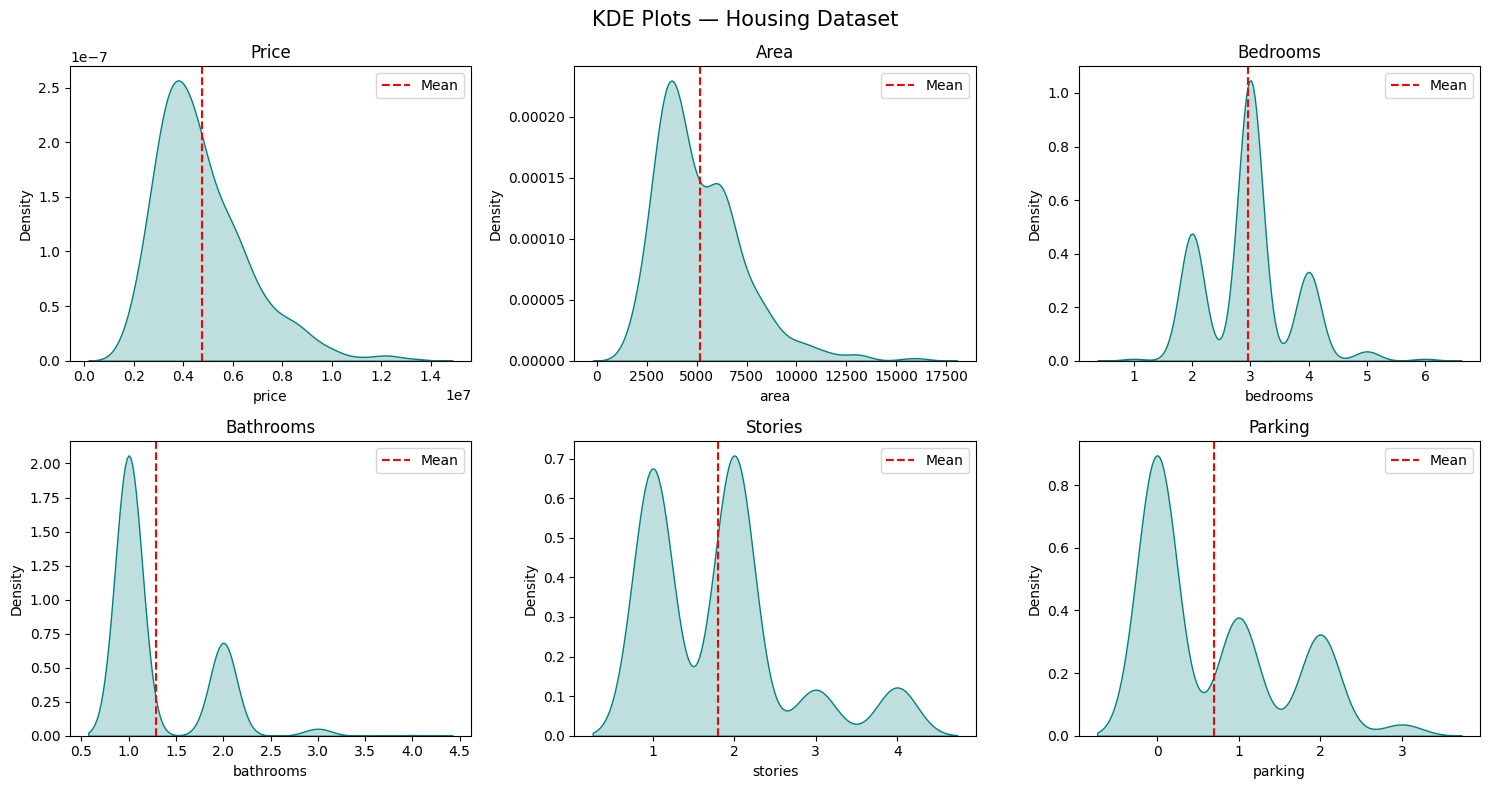

In [139]:
numeric_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 8))
plt.suptitle('KDE Plots — Housing Dataset', fontsize=15)

for i, col in enumerate(numeric_cols):
    # plt.subplot(rows, cols, index) -> index starts at 1
    plt.subplot(2, 3, i + 1) #2 row 3 column

    # 1.  KDE Plot
    sns.kdeplot(df[col], fill=True, color='teal')

    # 2.  Mean Line
    plt.axvline(df[col].mean(), color='red', linestyle='--', label='Mean')

    # 3. Titles and Labels
    plt.title(col.capitalize())
    plt.legend()

plt.tight_layout()
plt.show()

In [140]:
#finding Skewness
# Skewness = 0 --> perfectly symmetric (bell curve)
# Skewness > 0 --> right skewed (tail on the right)
# Skewness < 0 --> left skewed (tail on the left)
df[numeric_cols].skew()

,0
price,1.212239
area,1.321188
bedrooms,0.495684
bathrooms,1.589264
stories,1.082088
parking,0.842062


In [141]:
# Column      Skewness    Meaning
# ----------- ----------- --------------------
# price       1.21        Highly right skewed
# area        1.32        Highly right skewed
# bedrooms    0.49        Fairly symmetric
# bathrooms   1.58        Highly skewed
# stories     1.08        Highly skewed
# parking     0.84        Moderately skewed

In [142]:
df['price_log'] = np.log1p(df['price'])   # log transform price
df['area_log']  = np.log1p(df['area'])    # log transform area
df['bathroom_log'] = np.log1p(df['bathrooms']) #log transform bathrooms

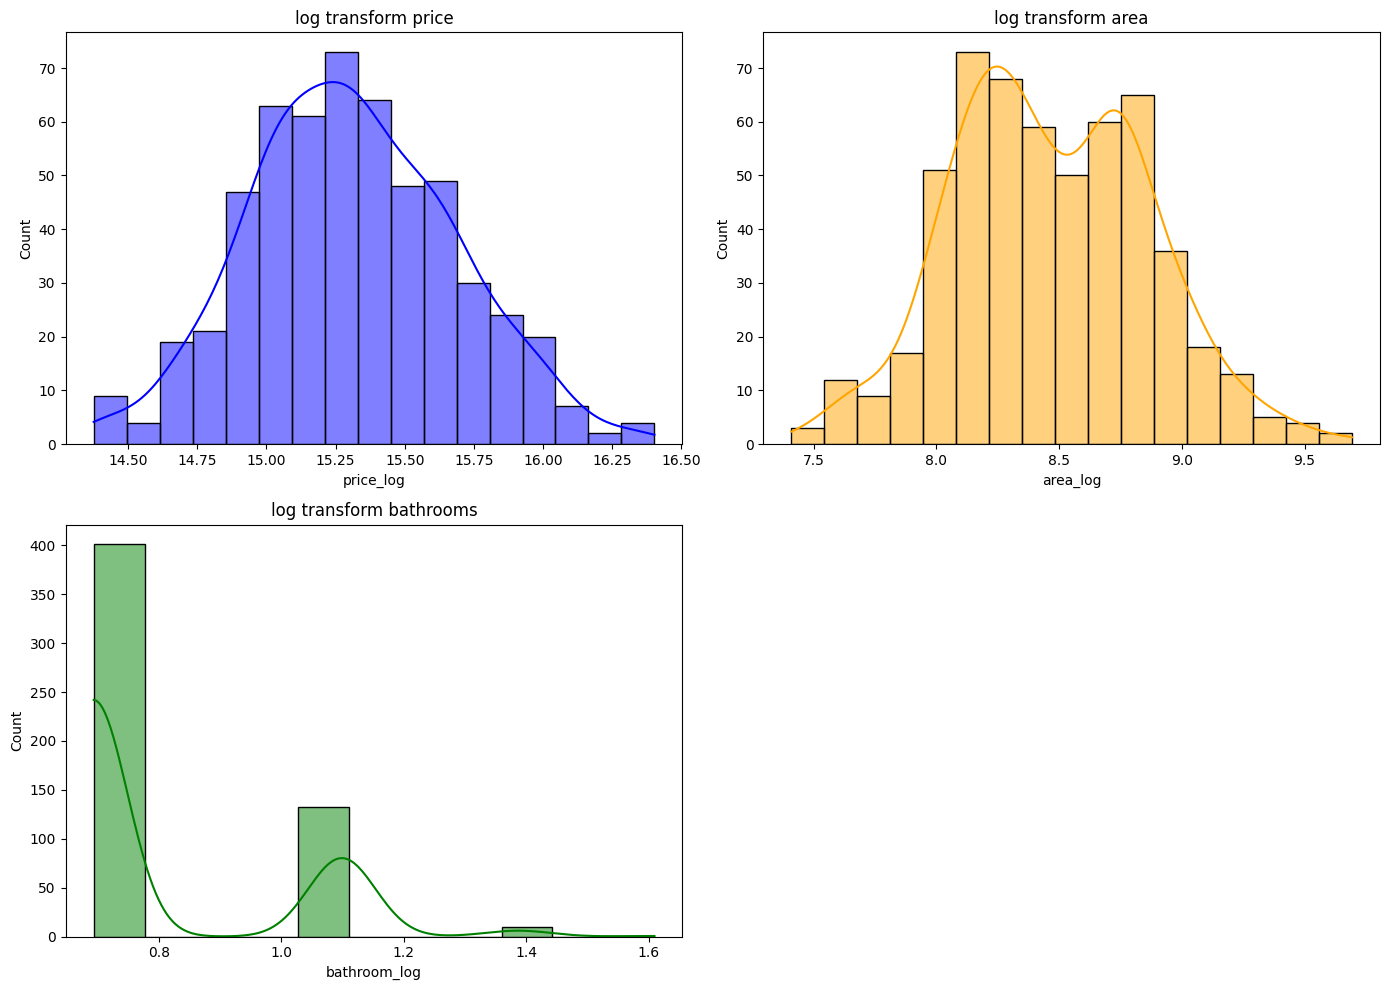

In [143]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['price_log'], kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('log transform price')

sns.histplot(df['area_log'], kde=True, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('log transform area')

sns.histplot(df['bathroom_log'], kde=True, color='green', ax=axes[1, 0])
axes[1, 0].set_title('log transform bathrooms')

axes[1][1].set_visible(False)


plt.tight_layout()
plt.show()

In [144]:
#now comparing skewness before and after log transformation
print(df[numeric_cols].skew())
new_numerical_cols = ['price_log', 'area_log', 'bedrooms', 'bathroom_log', 'stories', 'parking']
df[new_numerical_cols].skew()

price        1.212239
area         1.321188
bedrooms     0.495684
bathrooms    1.589264
stories      1.082088
parking      0.842062
dtype: float64


,0
price_log,0.140863
area_log,0.133747
bedrooms,0.495684
bathroom_log,1.310299
stories,1.082088
parking,0.842062


In [145]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_log,area_log,bathroom_log
76,6650000,6420,3,2,3,yes,no,no,no,yes,0,yes,furnished,15.710128,8.767329,1.098612
123,5950000,7320,4,2,2,yes,no,no,no,no,0,no,furnished,15.598902,8.898502,1.098612
516,2450000,3240,2,1,1,no,yes,no,no,no,1,no,unfurnished,14.711599,8.083637,0.693147
184,5110000,3000,3,2,2,yes,yes,yes,no,no,0,no,furnished,15.446710,8.006701,1.098612
260,4473000,3162,3,1,2,yes,no,no,no,yes,1,no,furnished,15.313570,8.059276,0.693147


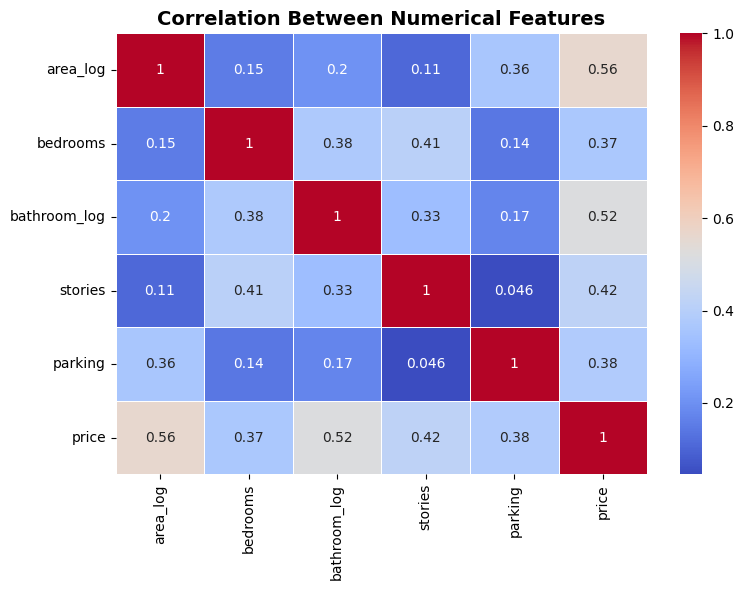

In [146]:
#Visulize the correlation between Neumerical Data by heat map
new_numerical_cols = ['area_log', 'bedrooms', 'bathroom_log', 'stories', 'parking','price']

corr_matrix = df[new_numerical_cols].corr()   # calculate correlation matrix

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix,
            annot=True,          # show numbers inside boxes
            cmap='coolwarm',     # red=high, blue=low correlation
            linewidths=0.5,      # gap between boxes
            linecolor='white',   # color of gap
            )

plt.title('Correlation Between Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [147]:
#Most important columns
corr_matrix['price'].sort_values(ascending=False)

,price
price,1.000000
area_log,0.561233
bathroom_log,0.516704
stories,0.420712
parking,0.384394
bedrooms,0.366494


In [148]:
df.drop(columns=['price','area','bathrooms'],inplace=True)

In [149]:
df.sample(5)

,bedrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_log,area_log,bathroom_log
2,3,2,yes,no,yes,no,no,2,yes,semi-furnished,16.321037,9.206433,1.098612
382,3,2,yes,no,yes,no,no,0,no,furnished,15.088076,8.055475,0.693147
131,4,4,yes,yes,no,no,no,0,no,semi-furnished,15.575091,8.670601,0.693147
139,3,1,yes,yes,yes,no,yes,2,yes,furnished,15.562970,8.757941,0.693147
376,3,2,yes,no,no,no,no,2,no,semi-furnished,15.107495,8.326275,1.098612


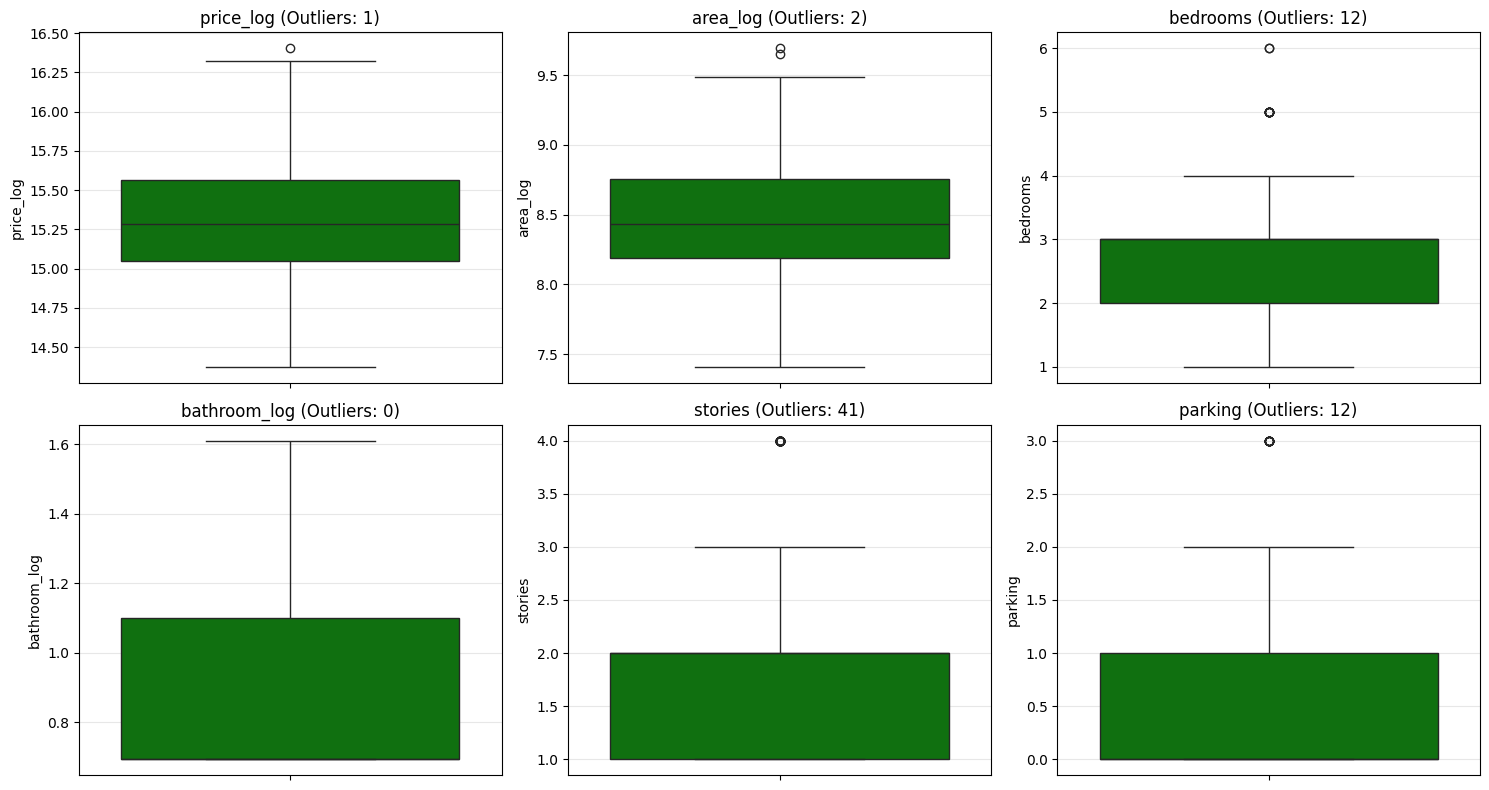

In [150]:
# Create a figure
plt.figure(figsize=(15, 8))

# Redefine new_numerical_cols to use 'price_log' since 'price' was dropped
new_numerical_cols = ['price_log', 'area_log', 'bedrooms', 'bathroom_log', 'stories', 'parking']

for i, col in enumerate(new_numerical_cols):
    # Select the plot position (1 to 6)
    plt.subplot(2, 3, i + 1)


    sns.boxplot(y=df[col], color='green')

    #  outlier calculation
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]

    plt.title(f'{col} (Outliers: {outliers})')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [151]:
from sklearn.model_selection import train_test_split
y = (df['price_log'])
X = df.drop(columns=['price_log'])

# 3. Perform the Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape:  {X_test.shape}")

Training features shape: (436, 12)
Testing features shape:  (109, 12)


In [152]:
df.head()

,bedrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_log,area_log,bathroom_log
0,4,3,yes,no,no,no,yes,2,yes,furnished,16.403275,8.912069,1.098612
1,4,4,yes,no,no,no,yes,3,no,furnished,16.321037,9.100637,1.609438
2,3,2,yes,no,yes,no,no,2,yes,semi-furnished,16.321037,9.206433,1.098612
3,4,2,yes,no,yes,no,yes,3,yes,furnished,16.318175,8.922792,1.098612
4,4,2,yes,yes,yes,no,yes,2,no,furnished,16.250001,8.912069,0.693147


In [153]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [154]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#  Identify column types
num_cols = ['area_log', 'bathroom_log', 'bedrooms', 'stories', 'parking']
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
            'airconditioning', 'prefarea', 'furnishingstatus']

#  Scale numerical features
# Fit ONLY on train, then transform both (prevents data leakage)
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num  = scaler.transform(X_test[num_cols])

X_train_num_df = pd.DataFrame(X_train_num, columns=num_cols, index=X_train.index)
X_test_num_df  = pd.DataFrame(X_test_num,  columns=num_cols, index=X_test.index)

# --- Encode categorical features ---
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat  = ohe.transform(X_test[cat_cols])

cat_encoded_cols = ohe.get_feature_names_out(cat_cols)
X_train_cat_df = pd.DataFrame(X_train_cat, columns=cat_encoded_cols, index=X_train.index)
X_test_cat_df  = pd.DataFrame(X_test_cat,  columns=cat_encoded_cols, index=X_test.index)

#  Combine scaled numerical + encoded categorical
X_train_final = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
X_test_final  = pd.concat([X_test_num_df,  X_test_cat_df],  axis=1)

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape: ", X_test_final.shape)

X_train_final shape: (436, 13)
X_test_final shape:  (109, 13)


In [155]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [156]:
lr = LinearRegression()
lr.fit(X_train_final, y_train)

LinearRegression()

In [157]:
y_pred_log = lr.predict(X_test_final)

In [158]:
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

In [159]:
r2  = r2_score(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)

print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:,.0f}")

R²   : 0.6594
RMSE : 1,312,080


In [160]:
train_r2 = r2_score(np.expm1(y_train), np.expm1(lr.predict(X_train_final)))
test_r2  = r2_score(y_test_actual, y_pred_actual)

print(f"Train R² : {train_r2:.4f}")
print(f"Test  R² : {test_r2:.4f}")
print(f"Gap      : {train_r2 - test_r2:.4f}")

Train R² : 0.7019
Test  R² : 0.6594
Gap      : 0.0425


In [161]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# Instantiate and fit the Ridge model
ridge = Ridge(alpha=0.01)  # You can adjust alpha, 1.0 is default
ridge.fit(X_train_final, y_train)

#  predictions on BOTH sets
y_pred_ridge_train = np.expm1(ridge.predict(X_train_final))
y_pred_ridge_test = np.expm1(ridge.predict(X_test_final))

#  R² for both
train_r2 = r2_score(np.expm1(y_train), y_pred_ridge_train)
test_r2  = r2_score(y_test_actual,      y_pred_ridge_test)
gap      = train_r2 - test_r2

print(f"Train R² : {train_r2:.4f}")
print(f"Test  R² : {test_r2:.4f}")
print(f"Gap      : {gap:.4f}")

Train R² : 0.7019
Test  R² : 0.6594
Gap      : 0.0425


In [162]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'max_depth'        : [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf' : [1, 2, 4, 8, 10],
    'max_features'     : ['sqrt', 'log2', None],
    'criterion'        : ['squared_error', 'absolute_error']
}

dt_base = DecisionTreeRegressor(random_state=42)

search = RandomizedSearchCV(
    estimator  = dt_base,
    param_distributions = param_grid,
    n_iter     = 100,          # try 100 random combinations
    cv         = 5,            # 5-fold cross validation
    scoring    = 'r2',
    n_jobs     = -1,           # use all CPU cores
    random_state = 42
)

search.fit(X_train_final, y_train)

print("Best parameters :", search.best_params_)
print("Best CV R²      :", round(search.best_score_, 4))

Best parameters : {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 6, 'criterion': 'squared_error'}
Best CV R²      : 0.5818


In [163]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'        : [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf' : [1, 2, 4, 8, 10],
    'max_features'     : ['sqrt', 'log2', None],
    'criterion'        : ['squared_error', 'absolute_error']
}

dt_base = DecisionTreeRegressor(random_state=42)

search = GridSearchCV(
    estimator  = dt_base,
    param_grid = param_grid, # Changed from param_distributions
    cv         = 5,            # 5-fold cross validation
    scoring    = 'r2',
    n_jobs     = -1           # use all CPU cores
    # random_state is not a parameter for GridSearchCV
)

search.fit(X_train_final, y_train)

print("Best parameters :", search.best_params_)
print("Best CV R²      :", round(search.best_score_, 4))

Best parameters : {'criterion': 'squared_error', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV R²      : 0.5818


In [164]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [2, 4, 6, 8],
    'max_features'     : ['sqrt', 'log2'],
}

rf_base = RandomForestRegressor(random_state=42, oob_score=True)

search = GridSearchCV(
    estimator           = rf_base,
    param_grid          = param_grid,
    cv                  = 5,
    scoring             = 'r2',
    n_jobs              = -1,

)

search.fit(X_train_final, y_train)

print("Best params :", search.best_params_)
print("Best CV R²  :", round(search.best_score_, 4))

Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²  : 0.6692


In [165]:
from sklearn.ensemble import VotingRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import numpy as np

voting2 = VotingRegressor(estimators=[
    ('ridge', Ridge(alpha=1.0)),
    ('gb',    GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                        max_depth=4, min_samples_leaf=5,
                                        subsample=0.8, random_state=42)),
    ('rf',    RandomForestRegressor(n_estimators=300, max_depth=8,
                                    min_samples_leaf=4, random_state=42))
])

voting2.fit(X_train_final, y_train)

y_pred_v2 = np.expm1(voting2.predict(X_test_final))
v2_cv = cross_val_score(voting2, X_train_final, y_train, cv=5, scoring='r2')

print(f"Voting2 Test R²  : {r2_score(y_test_actual, y_pred_v2):.4f}")
print(f"Voting2 CV R²    : {v2_cv.mean():.4f} ± {v2_cv.std():.4f}")

Voting2 Test R²  : 0.6371
Voting2 CV R²    : 0.6816 ± 0.0244


In [166]:
# Use the best params but constrain depth:
best_rf = RandomForestRegressor(
    n_estimators=300,       # more trees = more stable
    max_depth=8,            # prevent overgrowth
    min_samples_leaf=4,     # each leaf needs more samples
    min_samples_split=5,
    max_features='sqrt',
    oob_score=True,
    random_state=42
)
best_rf.fit(X_train_final, y_train)
print("OOB R²:", round(best_rf.oob_score_, 4))  # free validation estimate

OOB R²: 0.6564


In [167]:
from xgboost import XGBRegressor

xgb_base = XGBRegressor(random_state=42, verbosity=0)
xgb_base.fit(X_train_final, y_train)

train_r2 = r2_score(np.expm1(y_train), np.expm1(xgb_base.predict(X_train_final)))
test_r2  = r2_score(y_test_actual,      np.expm1(xgb_base.predict(X_test_final)))

print(f"Train R² : {train_r2:.4f}")
print(f"Test  R² : {test_r2:.4f}")
print(f"Gap      : {train_r2 - test_r2:.4f}")
print("→ default XGBoost before tuning")

Train R² : 0.9969
Test  R² : 0.6163
Gap      : 0.3806
→ default XGBoost before tuning


In [168]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha'       : [0, 0.01, 0.1, 1],    # L1 penalty (like Lasso)
    'reg_lambda'      : [1, 2, 5, 10],         # L2 penalty (like Ridge)
}

xgb = XGBRegressor(random_state=42, verbosity=0)

search_xgb = RandomizedSearchCV(
    estimator           = xgb,
    param_distributions = param_grid,
    n_iter              = 100,
    cv                  = 5,
    scoring             = 'r2',
    n_jobs              = -1,
    random_state        = 42
)

search_xgb.fit(X_train_final, y_train)

print("Best params :", search_xgb.best_params_)
print("Best CV R²  :", round(search_xgb.best_score_, 4))

Best params : {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV R²  : 0.6689


In [169]:
best_xgb = search_xgb.best_estimator_
y_pred_xgb_train = np.expm1(best_xgb.predict(X_train_final))
y_pred_xgb_test  = np.expm1(best_xgb.predict(X_test_final))

In [170]:
train_r2 = r2_score(np.expm1(y_train), y_pred_xgb_train)
test_r2  = r2_score(y_test_actual,      y_pred_xgb_test)
gap      = train_r2 - test_r2
rmse     = np.sqrt(mean_squared_error(y_test_actual, y_pred_xgb_test))

print(f"Train R²  : {train_r2:.4f}")
print(f"Test  R²  : {test_r2:.4f}")
print(f"Gap       : {gap:.4f}")
print(f"RMSE      : Rs.{rmse:,.0f}")

Train R²  : 0.8371
Test  R²  : 0.6255
Gap       : 0.2116
RMSE      : Rs.1,375,785


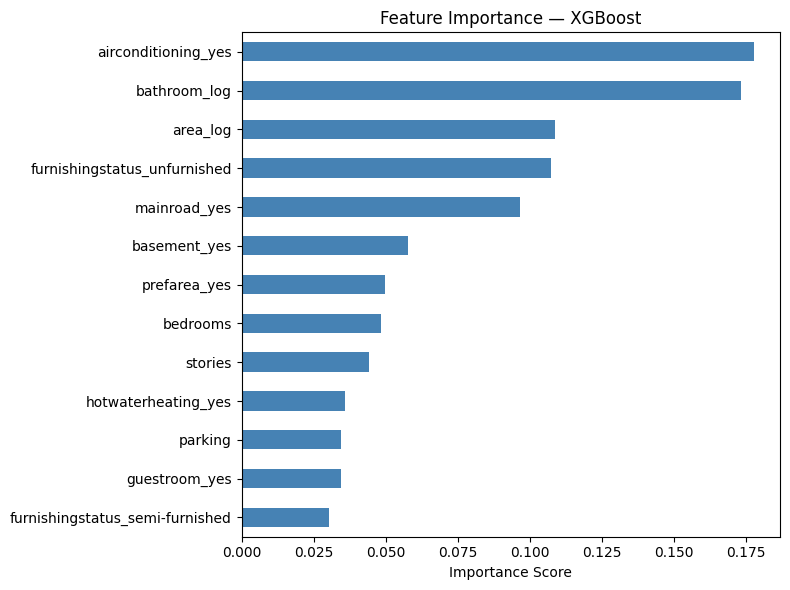

In [171]:
feat_imp = pd.Series(
    best_xgb.feature_importances_,
    index=X_train_final.columns
).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

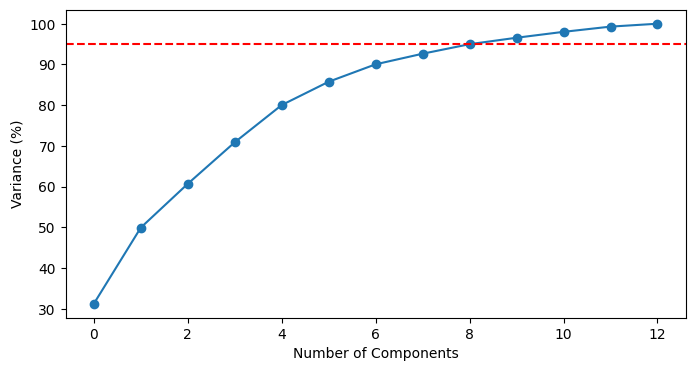

In [172]:
from sklearn.decomposition import PCA
pca = PCA()

pca.fit(X_train_final)
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100

# 3. Simple Plotting
plt.figure(figsize=(8, 4))
plt.plot(cum_var, marker='o')
plt.axhline(y=95, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Variance (%)')
plt.show()

In [173]:
from xgboost import XGBRegressor
from sklearn.decomposition import PCA

# apply PCA keeping 95% variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_final)
X_test_pca  = pca.transform(X_test_final)

print(f"Features before PCA : {X_train_final.shape[1]}")
print(f"Features after PCA  : {X_train_pca.shape[1]}")

xgb_pca = XGBRegressor(**search_xgb.best_params_, random_state=42, verbosity=0)
xgb_pca.fit(X_train_pca, y_train)

y_pred_pca_train = np.expm1(xgb_pca.predict(X_train_pca))
y_pred_pca_test  = np.expm1(xgb_pca.predict(X_test_pca))

train_r2_pca = r2_score(np.expm1(y_train), y_pred_pca_train)
test_r2_pca  = r2_score(y_test_actual,      y_pred_pca_test)
gap_pca      = train_r2_pca - test_r2_pca

print("WITHOUT PCA:")
print(f"  Train R² : {train_r2:.4f}")
print(f"  Test  R² : {test_r2:.4f}")
print(f"  Gap      : {gap:.4f}")

print("\nWITH PCA:")
print(f"  Train R² : {train_r2_pca:.4f}")
print(f"  Test  R² : {test_r2_pca:.4f}")
print(f"  Gap      : {gap_pca:.4f}")

Features before PCA : 13
Features after PCA  : 10
WITHOUT PCA:
  Train R² : 0.8371
  Test  R² : 0.6255
  Gap      : 0.2116

WITH PCA:
  Train R² : 0.8987
  Test  R² : 0.6217
  Gap      : 0.2771


In [174]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, min_samples_leaf=5,
    subsample=0.8, random_state=42
)
gb.fit(X_train_final, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, min_samples_leaf=5,
                          n_estimators=300, random_state=42, subsample=0.8)

In [175]:
print("=" * 40)
print("PCA VERDICT: NOT NEEDED")
print("=" * 40)
print(f"Without PCA → Test R² : 0.6255  Gap : 0.2116")
print(f"With PCA    → Test R² : 0.6217  Gap : 0.2771")
print()
print("Reason: Only 13 features, all meaningful.")
print("PCA removed 3 features and lost real signal.")
print("Final model → XGBoost WITHOUT PCA.")

PCA VERDICT: NOT NEEDED
Without PCA → Test R² : 0.6255  Gap : 0.2116
With PCA    → Test R² : 0.6217  Gap : 0.2771

Reason: Only 13 features, all meaningful.
PCA removed 3 features and lost real signal.
Final model → XGBoost WITHOUT PCA.


In [176]:
def predict_price(area, bedrooms, bathrooms, stories,
                  mainroad, guestroom, basement, hotwaterheating,
                  airconditioning, parking, prefarea, furnishingstatus):

    input_dict = {
        'area_log'    : np.log1p(area),
        'bathroom_log': np.log1p(bathrooms),
        'bedrooms'    : bedrooms,
        'stories'     : stories,
        'parking'     : parking,
        'mainroad'    : mainroad,
        'guestroom'   : guestroom,
        'basement'    : basement,
        'hotwaterheating': hotwaterheating,
        'airconditioning': airconditioning,
        'prefarea'    : prefarea,
        'furnishingstatus': furnishingstatus
    }

    num_cols = ['area_log', 'bathroom_log', 'bedrooms', 'stories', 'parking']
    cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                'airconditioning', 'prefarea', 'furnishingstatus']

    df_in = pd.DataFrame([input_dict])
    num_scaled = scaler.transform(df_in[num_cols])
    cat_encoded = ohe.transform(df_in[cat_cols])

    X_input = np.hstack([num_scaled, cat_encoded])

    price = np.expm1(best_xgb.predict(X_input)[0])
    print(f"Predicted Price : Rs.{price:,.0f}")
    return price

# --- test it ---
predict_price(
    area=5750, bedrooms=3, bathrooms=2, stories=4,
    mainroad='yes', guestroom='yes', basement='no',
    hotwaterheating='no', airconditioning='yes',
    parking=1, prefarea='yes', furnishingstatus='unfurnished'
)

Predicted Price : Rs.7,204,170


np.float32(7204169.5)

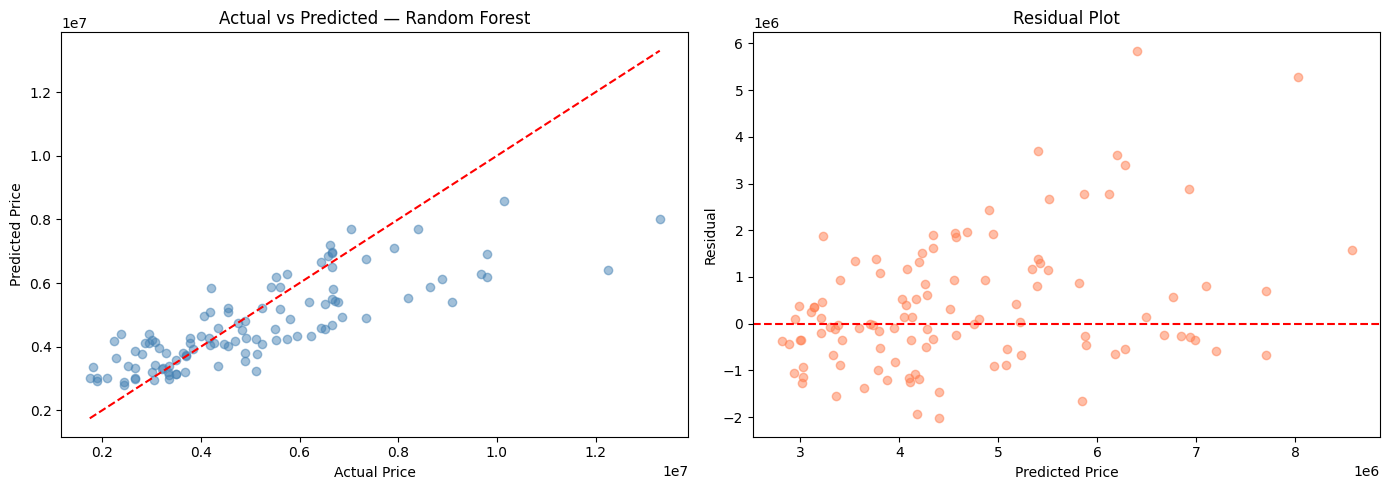

In [177]:
y_pred_rf = np.expm1(search.best_estimator_.predict(X_test_final))
residuals  = y_test_actual - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_actual, y_pred_rf, alpha=0.5, color='steelblue')
axes[0].plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()], 'r--')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted — Random Forest')

# Residuals
axes[1].scatter(y_pred_rf, residuals, alpha=0.5, color='coral')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()